         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


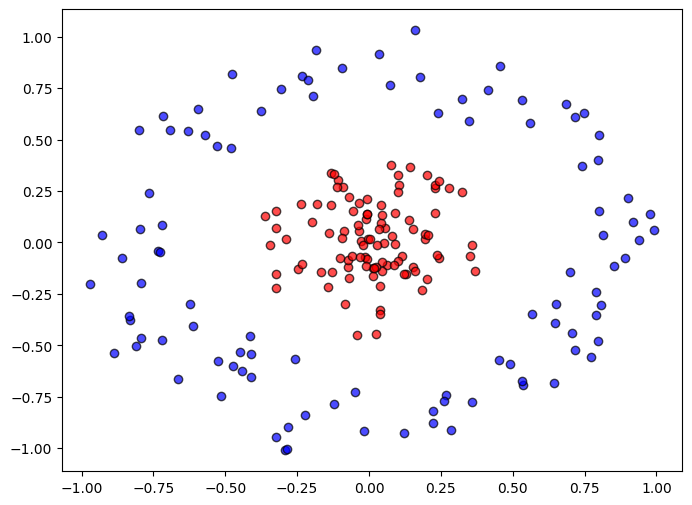

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Configurar semilla para reproducibilidad
np.random.seed(42)
 
# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2
 
# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)
 
# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)
 
# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])
 
# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido
 
# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})
 
# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())
 
# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='red', label='Maligna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='blue', label='Benigna (1)', alpha=0.7, edgecolors='k')

Iteration 1, loss = 0.79711563
Iteration 2, loss = 0.74263298
Iteration 3, loss = 0.71648166
Iteration 4, loss = 0.69691714
Iteration 5, loss = 0.68272828
Iteration 6, loss = 0.67583685
Iteration 7, loss = 0.67073580
Iteration 8, loss = 0.66372622
Iteration 9, loss = 0.65350442
Iteration 10, loss = 0.64019001
Iteration 11, loss = 0.62683520
Iteration 12, loss = 0.61573073
Iteration 13, loss = 0.60639436
Iteration 14, loss = 0.59718979
Iteration 15, loss = 0.58800292
Iteration 16, loss = 0.57837168
Iteration 17, loss = 0.56805737
Iteration 18, loss = 0.55767720
Iteration 19, loss = 0.54771469
Iteration 20, loss = 0.53779412
Iteration 21, loss = 0.52844907
Iteration 22, loss = 0.52107328
Iteration 23, loss = 0.51509546
Iteration 24, loss = 0.50872487
Iteration 25, loss = 0.50110330
Iteration 26, loss = 0.49264946
Iteration 27, loss = 0.48222365
Iteration 28, loss = 0.47039212
Iteration 29, loss = 0.45672605
Iteration 30, loss = 0.44068724
Iteration 31, loss = 0.42175584
Iteration 32, los

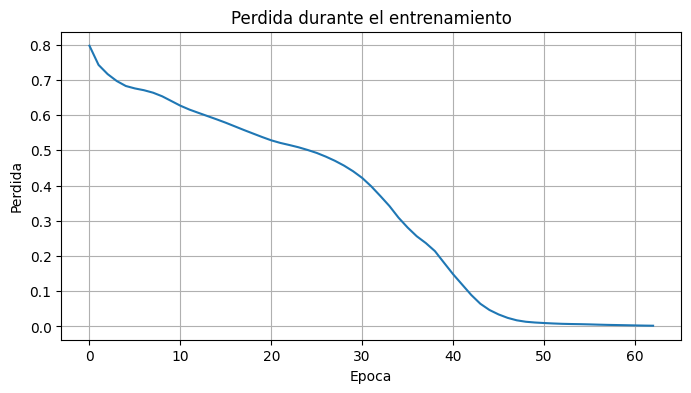

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

MLP_modelo = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    learning_rate_init=0.03,
    max_iter=100,
    batch_size='auto',
    early_stopping=False,
    tol=0.001,
    n_iter_no_change=10,
    verbose=True,
    random_state=42
)

MLP_modelo.fit(X_train, y_train)

predicciones = MLP_modelo.predict(X_test)
print(f'\nEpocas ejecutadas: {MLP_modelo.n_iter_}')
print(f'Exactitud en prueba: {accuracy_score(y_test, predicciones):.3f}')
print('\nReporte de clasificacion:')
print(classification_report(y_test, predicciones))

plt.figure(figsize=(8, 4))
plt.plot(MLP_modelo.loss_curve_)
plt.xlabel('Epoca')
plt.ylabel('Perdida')
plt.title('Perdida durante el entrenamiento')
plt.grid(True)
plt.show()

In [10]:
MLP_modelo.fit(X, y)

Iteration 1, loss = 0.79760027
Iteration 2, loss = 0.74333155
Iteration 3, loss = 0.71734086
Iteration 4, loss = 0.69805752
Iteration 5, loss = 0.68430970
Iteration 6, loss = 0.67775199
Iteration 7, loss = 0.67300852
Iteration 8, loss = 0.66652348
Iteration 9, loss = 0.65689550
Iteration 10, loss = 0.64389718
Iteration 11, loss = 0.63115020
Iteration 12, loss = 0.62104250
Iteration 13, loss = 0.61208199
Iteration 14, loss = 0.60322957
Iteration 15, loss = 0.59471857
Iteration 16, loss = 0.58567119
Iteration 17, loss = 0.57590131
Iteration 18, loss = 0.56617047
Iteration 19, loss = 0.55733310
Iteration 20, loss = 0.54875470
Iteration 21, loss = 0.53950396
Iteration 22, loss = 0.53152077
Iteration 23, loss = 0.52582980
Iteration 24, loss = 0.52002966
Iteration 25, loss = 0.51261894
Iteration 26, loss = 0.50394569
Iteration 27, loss = 0.49344494
Iteration 28, loss = 0.48277216
Iteration 29, loss = 0.47102803
Iteration 30, loss = 0.45721018
Iteration 31, loss = 0.44098607
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.03
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"tol tol: float, default=1e-4Tolerance for the optimization. When the loss or score is not improvingby at least ``tol`` for ``n_iter_no_change`` consecutive iterations,unless ``learning_rate`` is set to 'adaptive', convergence isconsidered to be reached and training stops.",0.001
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'


In [11]:
import joblib
joblib.dump(MLP_modelo, 'modelo_circulos.pkl')

['modelo_circulos.pkl']

In [12]:
predicciones = MLP_modelo.predict(X_test)
print(f'\nEpocas ejecutadas: {MLP_modelo.n_iter_}')
print(f'Exactitud en prueba: {accuracy_score(y_test, predicciones):.3f}')
print('\nReporte de clasificacion:')
print(classification_report(y_test, predicciones))


Epocas ejecutadas: 72
Exactitud en prueba: 1.000

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [15]:
# Prediccion para x1=0.1 y x2=0.1
nueva_celula = pd.DataFrame({'x1': [0.1], 'x2': [0.1]})

clase_predicha = int(MLP_modelo.predict(nueva_celula)[0])
probabilidades = MLP_modelo.predict_proba(nueva_celula)[0]
probabilidad_clase = probabilidades[clase_predicha]

# Convencion solicitada: 1 = maligna, 0 = benigna
nombre_clase = 'maligna' if clase_predicha == 1 else 'benigna'

print(f'Prediccion para x1=0.1 y x2=0.1: {clase_predicha}')
print(f'La celula es {nombre_clase}.')
print(f'Probabilidad de celula benigna (clase 1): {probabilidades[0]:.2%}')
print(f'Probabilidad de celula maligna (clase 0): {probabilidades[1]:.2%}')
print(f'Probabilidad de la clase predicha: {probabilidad_clase:.2%}')

Prediccion para x1=0.1 y x2=0.1: 0
La celula es benigna.
Probabilidad de celula benigna (clase 1): 100.00%
Probabilidad de celula maligna (clase 0): 0.00%
Probabilidad de la clase predicha: 100.00%
